# Challenge — Red neuronal con Keras 3
### Universidad EAFIT | SI3003 — Introducción a la Inteligencia Artificial

---

## Objetivo

En clase construimos una red neuronal de clasificación con **Keras 3**.

En este ejercicio vas a aplicar la misma receta sobre un dataset diferente:

> **Olivetti Faces**

El dataset contiene imágenes de rostros en escala de grises. El objetivo será identificar a cuál persona pertenece cada imagen.

No necesitas diseñar un pipeline de datos nuevo. La carga, división y visualización están resueltas.

Tu trabajo se concentra en completar las etapas principales de Keras:

```text
Datos
  ↓
Modelo
  ↓
Loss + Optimizer
  ↓
Entrenamiento
  ↓
Evaluación
  ↓
Predicción
```

---

## ¿Qué debes completar?

Las celdas marcadas con `# TODO` contienen espacios que debes completar.

El resto del código está preparado para que puedas concentrarte en los conceptos vistos en clase.


---
## 0. Importar librerías

Usaremos:

- **Keras 3** para construir y entrenar la red.
- **scikit-learn** para cargar Olivetti Faces y dividir los datos.
- **NumPy** para manipular arrays.
- **Matplotlib** para visualizar imágenes.


In [1]:
import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

SEED = 42
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Backend       : {keras.backend.backend()}")


Keras version : 3.15.1
Backend       : tensorflow


---
# 1. Dataset: Olivetti Faces

Olivetti Faces contiene:

- **400 imágenes**
- imágenes de **64 × 64 píxeles**
- escala de grises
- **40 personas**
- **10 imágenes por persona**

La etiqueta indica la identidad de la persona:

```text
0, 1, 2, ..., 39
```

Cada imagen ya viene representada con valores flotantes aproximadamente en el rango:

$$
[0,1]
$$

Por eso, en este ejercicio **no necesitamos normalizar dividiendo por 255**.


In [2]:
# Esta parte está resuelta.

faces = fetch_olivetti_faces(
    shuffle=True,
    random_state=SEED

)

X = faces.images
y = faces.target

print("X:", X.shape)
print("y:", y.shape)
print("Valor mínimo:", X.min())
print("Valor máximo:", X.max())
print("Número de clases:", len(np.unique(y)))


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\MANUEL TAFUR\scikit_learn_data
X: (400, 64, 64)
y: (400,)
Valor mínimo: 0.0
Valor máximo: 1.0
Número de clases: 40


## 1.1 Dividir entrenamiento y prueba

Como solo tenemos 10 imágenes por persona, debemos asegurarnos de que todas las identidades aparezcan tanto en entrenamiento como en prueba.

Usaremos una división **estratificada**:

```text
80% entrenamiento
20% prueba
```

La opción:

```python
stratify=y
```

mantiene la proporción de cada clase en ambos conjuntos.

Esta parte está resuelta.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nPersonas en train:", len(np.unique(y_train)))
print("Personas en test :", len(np.unique(y_test)))


X_train: (320, 64, 64)
X_test : (80, 64, 64)
y_train: (320,)
y_test : (80,)

Personas en train: 40
Personas en test : 40


### Pregunta 1

Cada imagen tiene tamaño:

$$
64 \times 64
$$

Cuando apliquemos `Flatten()`, ¿cuántos valores tendrá cada ejemplo?

**Respuesta:**

Cada ejemplo tendrá 4096 valores, ya que $64 \times 64 = 4096$.


---
## 1.2 Visualizar algunas imágenes

Esta parte está resuelta.

Observa que varias fotografías corresponden a la misma persona con pequeñas variaciones de expresión, iluminación y orientación.


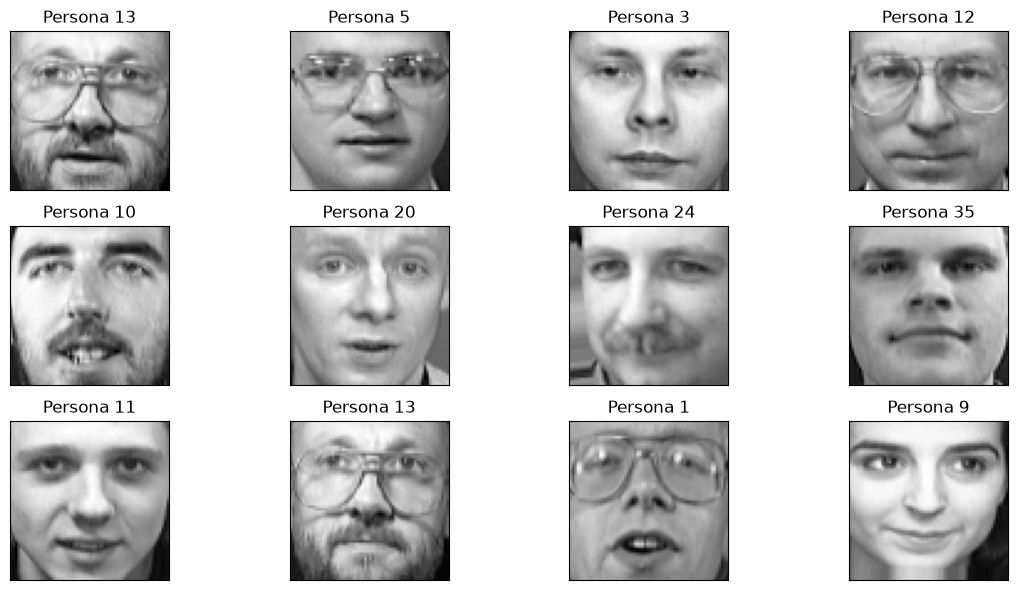

In [4]:
plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Persona {y_train[i]}")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


---
# 2. Construir la red neuronal

Usaremos una arquitectura fully-connected similar a la vista en clase:

```text
Imagen 64×64
     ↓
Flatten
     ↓
4096 valores
     ↓
Dense(64)
     ↓
ReLU
     ↓
Dense(40)
     ↓
Logits
```

La última capa debe tener una salida por cada clase.

> **Importante:** no añadas `Softmax` al final. Trabajaremos directamente con **logits**.


In [5]:
# TODO 1 — Completar la arquitectura.

model = keras.Sequential([

    keras.Input(shape=(64, 64)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dense(40)
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │         2,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 264,808 (1.01 MB)

 Trainable params: 264,808 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Validación TODO 1

assert isinstance(model, keras.Model)

# Dense(64): 4096*64 + 64
# Dense(40): 64*40 + 40
expected_params = (4096 * 64 + 64) + (64 * 40 + 40)

assert model.count_params() == expected_params, (
    f"Se esperaban {expected_params:,} parámetros, "
    f"pero el modelo tiene {model.count_params():,}."
)

print("✓ Arquitectura correcta.")
print(f"Parámetros entrenables: {model.count_params():,}")


✓ Arquitectura correcta.
Parámetros entrenables: 264,808


### Pregunta 2

¿Por qué necesitamos `Flatten()` antes de la primera capa `Dense`?

**Respuesta:**

Porque las capas `Dense` esperan recibir datos unidimensionales (vectores). `Flatten()` se encarga de aplanar la matriz bidimensional de la imagen (64x64) en un vector de una sola dimensión (4096) para poder alimentar las capas densas.

### Pregunta 3

¿Por qué la última capa tiene **40 neuronas**?

**Respuesta:**

Porque el dataset contiene imágenes de 40 personas diferentes (40 clases). En una tarea de clasificación multiclase, la última capa debe tener una neurona por cada clase para producir un logit o probabilidad para cada una.

### Pregunta 4

¿Qué función cumple `ReLU` en la capa oculta?

**Respuesta:**

`ReLU` introduce no-linealidad en la red neuronal. Esto es crucial para que el modelo pueda aprender relaciones y patrones complejos, ya que si solo se usaran operaciones lineales, todo el modelo equivaldría a una sola transformación lineal básica.


---
# 3. Configurar el entrenamiento

Las etiquetas son números enteros entre:

```text
0 y 39
```

Por eso usaremos:

```python
SparseCategoricalCrossentropy
```

Además:

- el modelo produce **logits**,
- usaremos **Adam**,
- mediremos **accuracy**.

Completa `model.compile()`.


In [7]:
lr_rate = 0.001

# TODO 2 — Configurar loss, optimizer y métrica.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_rate),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)
print("✓ Modelo configurado.")


✓ Modelo configurado.


### Pregunta 5

¿Por qué usamos:

```python
from_logits=True
```

en la función de pérdida?

**Respuesta:**

Porque la última capa de la red produce valores crudos (logits) y no aplica una función `Softmax`. Esto le dice a la función de pérdida que ella misma debe encargarse de calcular las probabilidades internamente para que la matemática sea más estable.



---
# 4. Entrenar el modelo

Usaremos:

```python
epochs = 30
batch_size = 32
```

El dataset es pequeño, por lo que el entrenamiento debería ser rápido.

Keras realizará internamente:

```text
Forward pass
      ↓
Calcular loss
      ↓
Backpropagation
      ↓
Actualizar parámetros con Adam
```

Completa la llamada a `fit()`.


In [8]:
epochs = 30
batch_size = 32

# TODO 3 — Entrenar el modelo.
history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    shuffle=True
)


Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.0156 - loss: 3.9050 - val_accuracy: 0.0250 - val_loss: 3.6889
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0250 - loss: 3.6890 - val_accuracy: 0.0250 - val_loss: 3.6889
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0188 - loss: 3.6890 - val_accuracy: 0.0250 - val_loss: 3.6889
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0219 - loss: 3.6890 - val_accuracy: 0.0250 - val_loss: 3.6889
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0219 - loss: 3.6890 - val_accuracy: 0.0250 - val_loss: 3.6889
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0219 - loss: 3.6890 - val_accuracy: 0.0250 - val_loss: 3.6889
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0219 - loss: 3.6890 - val_accuracy: 0.0250 - val_loss: 3.6889
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0250 - loss: 3.6890 - val_accuracy: 0.0250 - v

### Pregunta 6

¿Qué representa una **epoch**?

**Respuesta:**

Una `epoch` representa un paso completo de entrenamiento en el que la red ha visto y procesado absolutamente todo el conjunto de datos de entrenamiento una vez.

### Pregunta 7

¿Qué significa `batch_size=32`?

**Respuesta:**

Significa que el conjunto de entrenamiento se divide en grupos de 32 imágenes. La red procesa estas 32 imágenes juntas (mini-batch) y luego realiza una actualización de sus pesos.



---
## 4.1 Visualizar el entrenamiento

Esta parte está resuelta.

El dataset tiene muy pocos ejemplos comparado con el número de parámetros de la red.

Observa cuidadosamente la diferencia entre entrenamiento y validación.


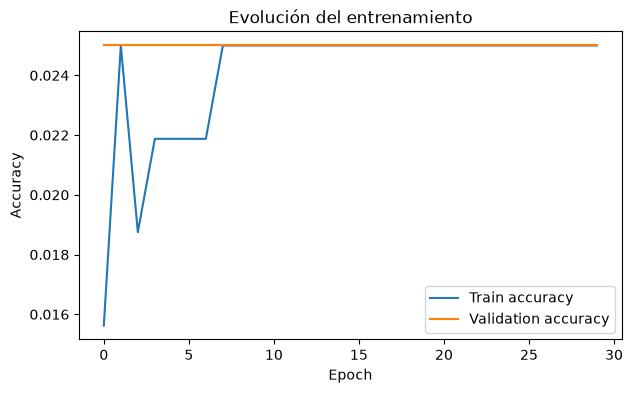

In [9]:
plt.figure(figsize=(7, 4))

plt.plot(
    history.history["accuracy"],
    label="Train accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolución del entrenamiento")
plt.legend()

plt.show()


### Pregunta 8

Observando la gráfica:

- ¿El accuracy de entrenamiento sigue aumentando?
**Respuesta:** El accuracy de entrenamiento cambia de manera irregular: aumenta, luego disminuye hasta un mínimo alrededor de la época 2, vuelve a subir y se mantiene en una meseta entre las épocas 3-6, para finalmente aumentar de nuevo y estabilizarse junto con el validation accuracy alrededor de la época 7.
- ¿El accuracy de validación se comporta igual?
**Respuesta:** El accuracy de validation se mantiene constante duerante todos los Epochs
- ¿Observas evidencia de **overfitting**?
**Respuesta:**Como el accuracy de entrenamiento y de validación llegan a encontrarse y permanecen juntos, no se presenta overfitting. Sin embargo, como podemos ver, la accuracy es bastante baja (~0.024), lo cual indica que el modelo no ha aprendido lo suficiente para clasificar correctamente los datos en cada clase; está generando los patrones de manera muy deficiente. Este comportamiento es característico de underfitting.




---
# 5. Evaluar el modelo

Ahora evaluaremos el modelo sobre imágenes que no fueron utilizadas para actualizar sus parámetros.

Completa `evaluate()`.


In [10]:
# TODO 4 — Evaluar.

test_loss, test_accuracy = model.evaluate(

    X_test,
    y_test,
    batch_size=batch_size,
    verbose=0
)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")
print(f"Accuracy (%)  : {test_accuracy * 100:.2f}%")


Test loss     : 3.6889
Test accuracy : 0.0250
Accuracy (%)  : 2.50%


### Pregunta 9

Tenemos **40 clases**, pero solamente **320 imágenes de entrenamiento**.

¿Crees que la cantidad de datos es grande o pequeña para una red con cientos de miles de parámetros?

**Respuesta:**
La cantidad de datos es inmensamente pequeña para una red con muchos parametros, pues tenemos solo en promedio 8 imagenes por clase, muy insuficiente para que el modelo aprenda patrones generales y robustos. Ademas, la cantidad de datos es tan escasa que el modelo ni siquiera logra extraer patrones útiles de las imágenes disponibles, resultando en underfitting como vimos en la gráfica anterior.


---
# 6. Logits y Softmax

La salida de nuestro modelo tiene forma:

```text
(batch_size, 40)
```

Cada uno de los 40 valores corresponde al **logit** asociado a una persona.

Los logits no son probabilidades.

Para convertirlos en probabilidades usamos:

```python
keras.ops.softmax(...)
```


In [ ]:
index = 0

image = X_test[index]
true_class = y_test[index]

plt.imshow(image, cmap="gray")
plt.title(f"Persona real: {true_class}")
plt.axis("off")
plt.show()

# Añadimos dimensión de batch:
# (64,64) -> (1,64,64)
image_batch = np.expand_dims(image, axis=0)

# Forward pass.
logits = model(
    image_batch,
    training=False
)

print("Shape de logits:", logits.shape)
print("\nPrimeros 10 logits:")
print(
    keras.ops.convert_to_numpy(logits)[0, :10]
)


In [ ]:
# TODO 5 — Convertir logits a probabilidades.

probabilities = keras.ops.softmax(logits)

# TODO 6 — Obtener la clase con mayor probabilidad.

prediction = keras.ops.argmax(
    probabilities,
    axis=1
)

prediction = int(
    keras.ops.convert_to_numpy(prediction)[0]
)

print()
print("Persona real     :", true_class)
print("Persona predicha :", prediction)


In [ ]:
# Revisamos las cinco clases con mayor probabilidad.

probabilities_np = keras.ops.convert_to_numpy(
    probabilities
)[0]

top5 = np.argsort(
    probabilities_np
)[-5:][::-1]

print("Top 5 predicciones:\n")

for class_id in top5:
    print(
        f"Persona {class_id:2d}: "
        f"{probabilities_np[class_id]:.4f}"
    )

print(
    "\nSuma de probabilidades:",
    probabilities_np.sum()
)


### Pregunta 10

¿Por qué la suma de las 40 probabilidades obtenidas con `Softmax` debe ser aproximadamente `1`?

**Respuesta:**La funcion softmax acota los numeros que obtenemos del logit, para que queden en un intervalo que esta entre 0 y 1. Como logit son los valores de las neuronas de la ultima capa, las cuales son los valores de las clasificaciones que tenemos, una neurona debe tener un valor mayor que las otras para que sea ese dato que recibimos sea perteneciente a una sola clase, por lo tanto para que esto se cumpla, se divide el puntaje exponencial de cada clase entre la suma total de todas las clases, se normalizan los resultados, permitiendo que el modelo seleccione la clase con mayor certeza asegurando que las probabilidades compitan entre sí. Y como sabemos la probabilidades juntas producen un 1 o 100% 



---
# 7. Visualizar varias predicciones

Esta parte está resuelta.

Observa especialmente los casos en los que el modelo se equivoca.


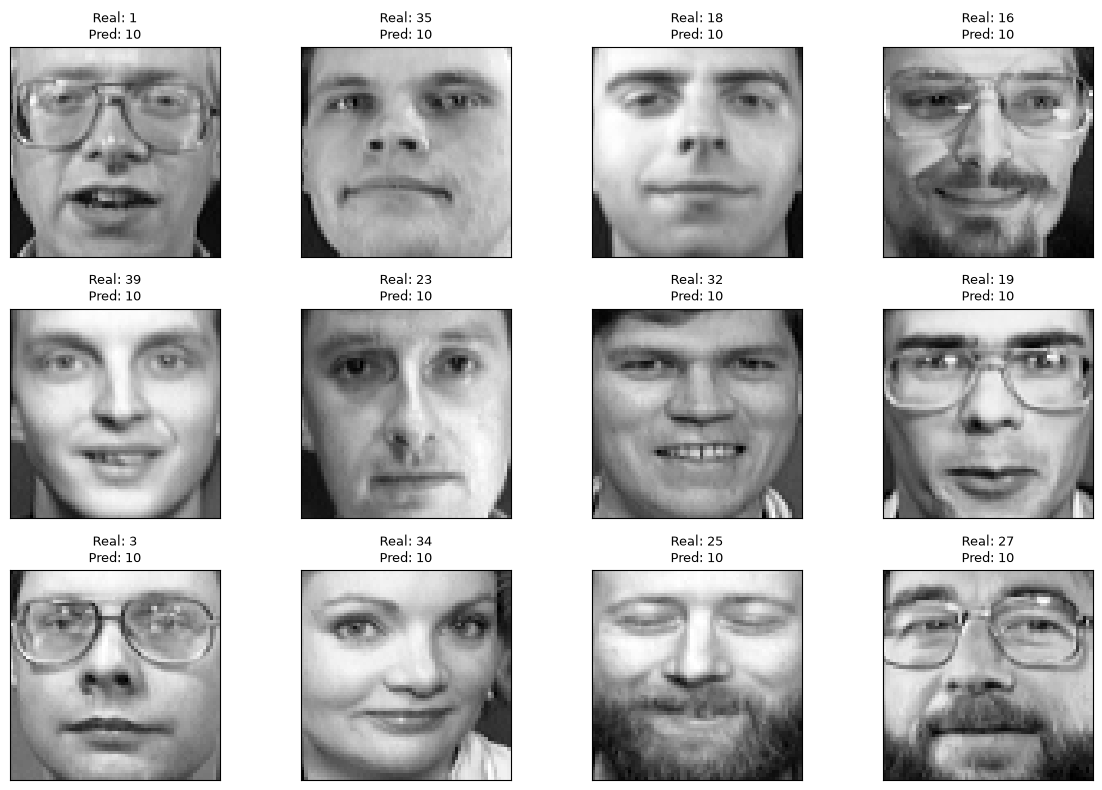

In [11]:
n = 12

logits_batch = model(
    X_test[:n],
    training=False
)

predictions = keras.ops.argmax(
    logits_batch,
    axis=1
)
predictions = keras.ops.convert_to_numpy(
    predictions
)

plt.figure(figsize=(12, 8))

for i in range(n):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        X_test[i],
        cmap="gray"
    )

    real = y_test[i]
    pred = predictions[i]

    plt.title(
        f"Real: {real}\nPred: {pred}",
        fontsize=9
    )

    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


---
# 8. Reflexión final

Responde brevemente.

### 1. ¿Cuál fue el accuracy final del modelo?

**Respuesta:**


### 2. ¿Observaste overfitting? ¿Qué evidencia utilizaste?

**Respuesta:** No observamos overfitting, en cambio underfitting debido a la escasez de datos que tenemos para entrenar y sacar patrones que nos ayuden a clasificar correctamente. 


### 3. ¿Qué ocurre cuando tenemos muchos parámetros pero pocos ejemplos de entrenamiento?

**Respuesta:** Se produce el overfitting, Al tener muchos parámetros (mucha capacidad) y pocos datos de entrenamiento, el modelo en lugar de aprender patrones generales válidos, memoriza los ejemplos específicos, lo que destruye su capacidad de generalizar ante información nueva.


### 4. Después de `Flatten()`, una cara de 64×64 se convierte en un vector de 4096 números.

¿Qué información sobre la estructura de la imagen deja de representar explícitamente esta transformación?

**Respuesta:**


### 5. ¿Crees que una arquitectura diseñada específicamente para imágenes podría aprovechar mejor la información espacial?

**Respuesta:**


---

## Para pensar

Nuestra red recibe:

```text
64 × 64
   ↓
Flatten
   ↓
4096 números
   ↓
Dense
```

Pero una imagen tiene una estructura espacial:

- píxeles cercanos están relacionados,
- existen bordes,
- existen formas,
- existen patrones locales.

Una red fully-connected no incorpora explícitamente esa estructura.

Esto motiva una arquitectura diseñada específicamente para imágenes:

> **Convolutional Neural Networks (CNNs)**


---
# Resumen

En este ejercicio aplicaste nuevamente la receta básica de entrenamiento de una red neuronal:

```text
Dataset
   ↓
Train / Test split
   ↓
Sequential
   ↓
Flatten
   ↓
Dense + ReLU
   ↓
Dense(40)
   ↓
Cross-Entropy
   ↓
Adam
   ↓
fit()
   ↓
evaluate()
```

Los componentes de Keras son los mismos que usamos en clase.

Lo que cambió fue:

- el dataset,
- el tamaño de las imágenes,
- el número de clases,
- y la dificultad del problema.
